# 💬 SMS dataset — EDA and preprocessing

Copenhagen Networks Study, `sms.csv`: `timestamp`, `sender`, `recipient`.
Per `sms.README` there is no documented sentinel value here (unlike calls'
`duration == -1`).

Steps covered: **(1) duplicates → (2) missing data → (3) outliers → (4)
scaling**, reusing `src/features/eda.py` (same helpers as `eda_calls.ipynb`).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.io import load_telecom_data, write_processed_data
from src.features import eda

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "7267433" / "sms.csv"
%matplotlib inline

In [2]:
data = load_telecom_data(RAW_PATH)
print(data.shape)
data.head()

(24333, 3)


,timestamp,sender,recipient
0,18,370,512
1,37,512,370
2,126,370,512
3,134,0,512
4,312,137,136


## (1) Duplicates

Unlike `calls.csv` (0 duplicates), check whether the same
`timestamp`+`sender`+`recipient` triple repeats — that would mean the same
message got logged twice.

In [3]:
eda.duplicate_report(data, subset=["timestamp", "sender", "recipient"])

{'n_rows': 24333, 'n_duplicate_rows': 21, 'pct_duplicate_rows': 0.0863}

**Decision:** exact duplicate rows exist. Two rows with the same
sender, recipient, *and* timestamp is not a second real message — SMS
timestamps in this dataset are second-resolution, so a genuine same-second
repeat message would be indistinguishable from a duplicate log entry
either way, and keeping it would double-count that pair's communication
volume. Dropped via `eda.drop_duplicate_rows`.

In [4]:
data = eda.drop_duplicate_rows(data, subset=["timestamp", "sender", "recipient"])
len(data)

24312

## (2) Missing data

In [5]:
eda.missingness_report(data)

,n_missing,pct_missing
timestamp,0,0.0
sender,0,0.0
recipient,0,0.0


**Decision:** 0 missing values in every column — no imputer needed.

## (3) Outliers

`sms.csv` has no intrinsic numeric measurement column (no duration/RSSI
equivalent). The meaningful numeric signal for this dataset is **messages
sent per sender** — a proxy for social/communication activity used later as
a "communication context" feature (per the project README). Outliers here
are unusually prolific senders, not bad rows.

In [6]:
messages_per_sender = data.groupby("sender").size().rename("sender_n_sent")
outlier_bounds = eda.outlier_report_iqr(messages_per_sender.to_frame(), "sender_n_sent")
outlier_bounds

{'column': 'sender_n_sent',
 'q1': 5.0,
 'q3': 36.5,
 'iqr': 31.5,
 'lower_bound': -42.25,
 'upper_bound': 83.75,
 'n_outliers': 52,
 'pct_outliers': 9.3694}

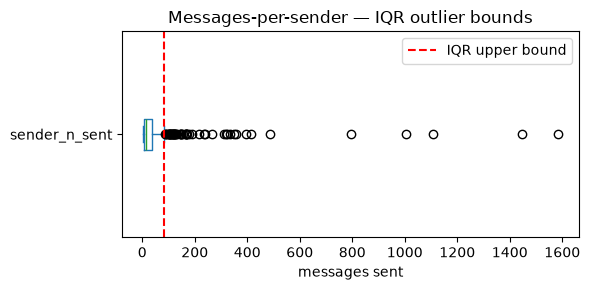

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
messages_per_sender.plot(kind="box", vert=False, ax=ax)
ax.set_xlabel("messages sent")
ax.set_title("Messages-per-sender — IQR outlier bounds")
ax.axvline(outlier_bounds["upper_bound"], color="red", linestyle="--", label="IQR upper bound")
ax.legend()
fig.tight_layout()

**Decision:** ~9% of senders are outliers by message volume (up to
1,585 messages from a single sender, vs. a median of 14). These are genuine
heavy users of SMS, not data errors, so they are **flagged** per-row
(broadcast from the sender back onto every message they sent) rather than
removed — removing them would silently delete a real (if unusual) sender's
entire communication history from downstream features.

In [8]:
outlier_senders = eda.flag_outliers_iqr(
    messages_per_sender.to_frame(), "sender_n_sent"
)["sender_n_sent_outlier"]

data = data.merge(
    messages_per_sender.rename("sender_n_sent"), on="sender", how="left"
)
data["sender_n_sent_outlier"] = data["sender"].map(outlier_senders)
data[["sender", "sender_n_sent", "sender_n_sent_outlier"]].drop_duplicates("sender").head()

,sender,sender_n_sent,sender_n_sent_outlier
0,370,20,False
1,512,357,True
3,0,62,False
4,137,321,True
5,278,167,True


## (4) Scaling

Scale `sender_n_sent` (a magnitude — activity volume) since it will feed
downstream models. `timestamp`, `sender`, and `recipient` are never scaled:
they are a temporal key and anonymous categorical participant IDs, not
measurements.

In [9]:
sender_activity = messages_per_sender.to_frame().reset_index()
scaled_activity, sender_activity_scaler = eda.scale_numeric_columns(
    sender_activity, ["sender_n_sent"], method="robust"
)

data = data.merge(
    scaled_activity[["sender", "sender_n_sent_scaled"]], on="sender", how="left"
)
data.head()

,timestamp,sender,recipient,sender_n_sent,sender_n_sent_outlier,sender_n_sent_scaled
0,18,370,512,20,False,0.190476
1,37,512,370,357,True,10.888889
2,126,370,512,20,False,0.190476
3,134,0,512,62,False,1.523810
4,312,137,136,321,True,9.746032


## (5)/(6) Balancing & encoding — not applicable here

No classification target exists to balance. `sender`/`recipient` are
anonymous **nominal** participant IDs, not ordered categories, so ordinal
encoding doesn't apply — it would invent a ranking between people that
isn't there.

## Result

`data` is the prepared dataframe for `sms.csv`:

- Exact duplicate messages (`timestamp`+`sender`+`recipient`) dropped.
- 0 true missing values (verified).
- `sender_n_sent` / `sender_n_sent_outlier` capture per-sender message
  volume and flag unusually prolific senders, without deleting their
  messages.
- `sender_n_sent_scaled` holds the median/IQR-scaled (`RobustScaler`)
  per-sender activity level — chosen over `StandardScaler` because the
  flagged high-volume senders are kept, not dropped, and would otherwise
  pull the mean/variance away from typical senders.

Saved separately from the raw pass-through `sms.parquet` produced by
`main.py`/`export_secondary_datasets`.

In [10]:
output_path = write_processed_data(data, PROJECT_ROOT / "data" / "processed", "sms_prepared.parquet")
output_path

PosixPath('/home/johnny/master_uu/UU-DataMining-2026/data/processed/sms_prepared.parquet')